ASSIGNMENT 1: Pandas DataFrame Master

In [1]:
import pandas as pd
import numpy as np

# Employees DataFrame
employees = pd.DataFrame({
    'emp_id':[1,2,3,4],
    'name':['Ali','Sara','John','Emma'],
    'dept_id':[101,102,101,103]
})

# Departments DataFrame
departments = pd.DataFrame({
    'dept_id':[101,102,103],
    'department':['HR','Finance','IT']
})

# Salaries DataFrame
salaries = pd.DataFrame({
    'emp_id':[1,2,3,4],
    'salary':[55000,72000,91000,65000]
})

print("Employees")
print(employees)

print("\nDepartments")
print(departments)

# 3. Merging
inner_join = pd.merge(employees, departments, on='dept_id', how='inner')
print("\nInner Join")
print(inner_join)

left_join = pd.merge(employees, departments, on='dept_id', how='left')
print("\nLeft Join")
print(left_join)

outer_join = pd.merge(employees, departments, on='dept_id', how='outer')
print("\nOuter Join")
print(outer_join)

# 4. Concatenate new employee
new_emp = pd.DataFrame({
    'emp_id':[5],
    'name':['David'],
    'dept_id':[102]
})

employees = pd.concat([employees,new_emp], ignore_index=True)
print("\nAfter Concatenation")
print(employees)

# 5. Merge employees with salaries
emp_salary = pd.merge(employees, salaries, on='emp_id', how='left')
print("\nEmployee Salary Data")
print(emp_salary)

# 6. Average salary by department
emp_salary = pd.merge(emp_salary, departments, on='dept_id', how='left')

avg_salary = emp_salary.groupby('department')['salary'].mean()
print("\nAverage Salary by Department")
print(avg_salary)

# 7. Salary Binning
bins = [0,60000,80000,100000]
labels = ['Low','Medium','High']

emp_salary['salary_category'] = pd.cut(emp_salary['salary'], bins=bins, labels=labels)

print("\nSalary Categories")
print(emp_salary)

# 8. Save CSV
emp_salary.to_csv("employee_summary.csv", index=False)

Employees
   emp_id  name  dept_id
0       1   Ali      101
1       2  Sara      102
2       3  John      101
3       4  Emma      103

Departments
   dept_id department
0      101         HR
1      102    Finance
2      103         IT

Inner Join
   emp_id  name  dept_id department
0       1   Ali      101         HR
1       2  Sara      102    Finance
2       3  John      101         HR
3       4  Emma      103         IT

Left Join
   emp_id  name  dept_id department
0       1   Ali      101         HR
1       2  Sara      102    Finance
2       3  John      101         HR
3       4  Emma      103         IT

Outer Join
   emp_id  name  dept_id department
0       1   Ali      101         HR
1       3  John      101         HR
2       2  Sara      102    Finance
3       4  Emma      103         IT

After Concatenation
   emp_id   name  dept_id
0       1    Ali      101
1       2   Sara      102
2       3   John      101
3       4   Emma      103
4       5  David      102

Employee Sa

ASSIGNMENT 2: Data Visualization with Pandas and Seaborn

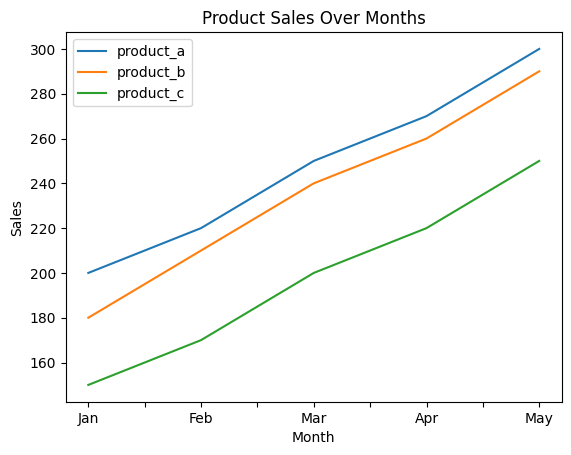

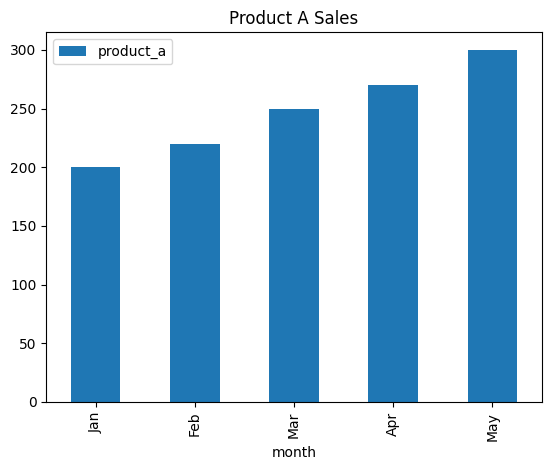

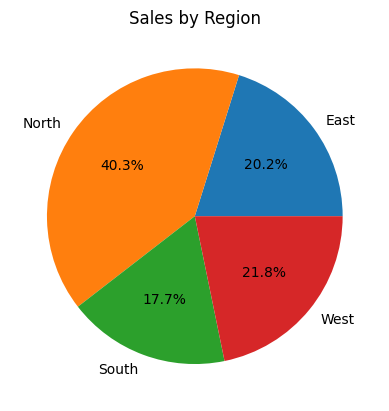

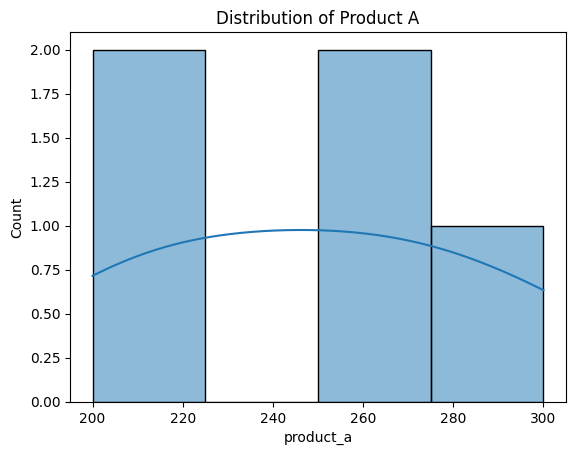

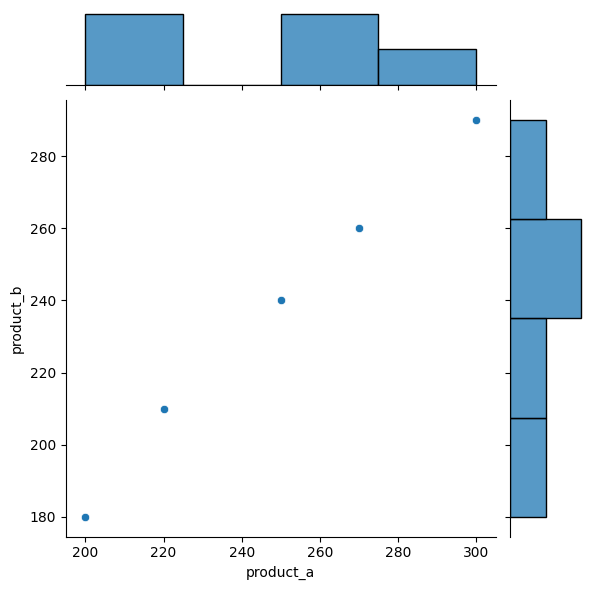

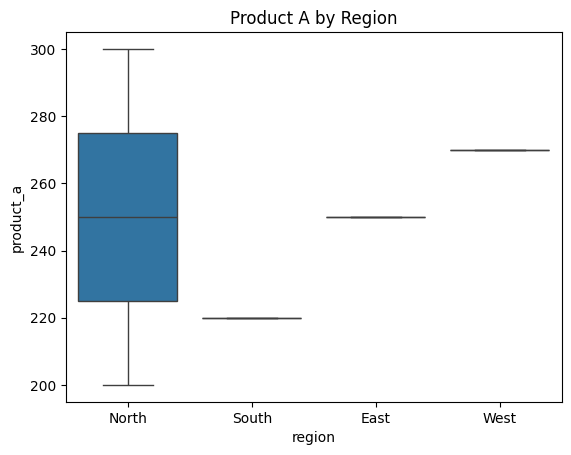

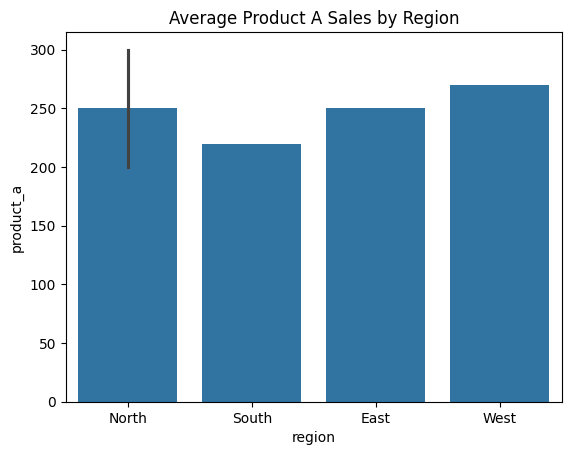

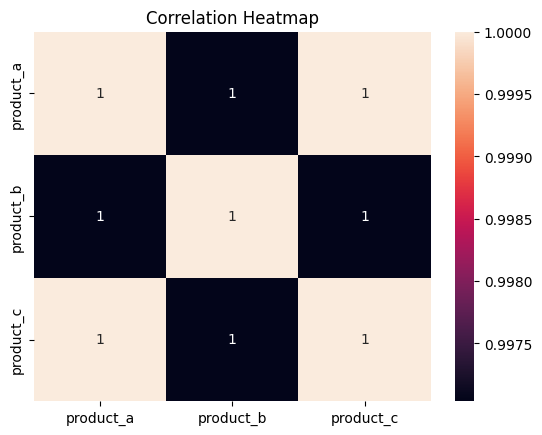

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
data = {
'month':['Jan','Feb','Mar','Apr','May'],
'product_a':[200,220,250,270,300],
'product_b':[180,210,240,260,290],
'product_c':[150,170,200,220,250],
'region':['North','South','East','West','North']
}

df = pd.DataFrame(data)

# Line Plot
df.set_index('month')[['product_a','product_b','product_c']].plot()
plt.title("Product Sales Over Months")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

# Bar Plot
df.plot(x='month', y='product_a', kind='bar')
plt.title("Product A Sales")
plt.show()

# Pie Chart
region_sales = df.groupby('region')['product_a'].sum()
region_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales by Region")
plt.show()

# Seaborn Distribution
sns.histplot(df['product_a'], kde=True)
plt.title("Distribution of Product A")
plt.show()

# Jointplot
sns.jointplot(x='product_a', y='product_b', data=df)
plt.show()

# Boxplot
sns.boxplot(x='region', y='product_a', data=df)
plt.title("Product A by Region")
plt.show()

# Barplot
sns.barplot(x='region', y='product_a', data=df)
plt.title("Average Product A Sales by Region")
plt.show()

# Correlation Matrix
corr = df[['product_a','product_b','product_c']].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

ASSIGNMENT 3: Simple Linear Regression from Scratch

Epoch: 0 Cost: 5578.125
Epoch: 100 Cost: 156.6256703318927
Epoch: 200 Cost: 71.29376628889617
Epoch: 300 Cost: 32.954184864290724
Epoch: 400 Cost: 15.728230277911138
Epoch: 500 Cost: 7.988617575160794
Epoch: 600 Cost: 4.511213493535093
Epoch: 700 Cost: 2.9488175944986885
Epoch: 800 Cost: 2.246833905509483
Epoch: 900 Cost: 1.9314329882958716

Final Slope: 6.740413162080412
Final Intercept: 42.643570526059335
Prediction for 4.5 hours: 72.97542975542119
Prediction for 7.5 hours: 93.19666924166242


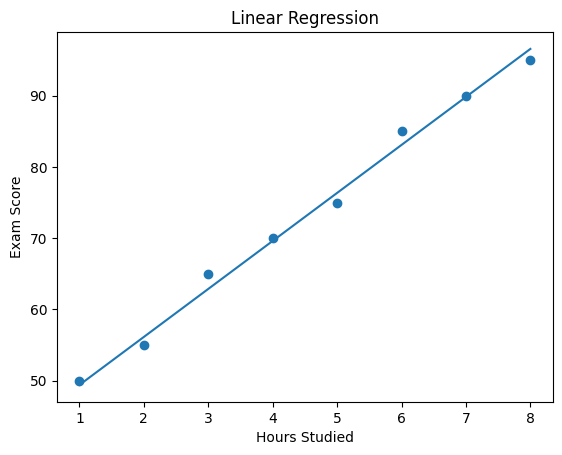

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Dataset
X = np.array([1,2,3,4,5,6,7,8])
y = np.array([50,55,65,70,75,85,90,95])

# Parameters
m = 0
b = 0
learning_rate = 0.01
epochs = 1000
n = len(X)

# Gradient Descent
for i in range(epochs):

    y_pred = m*X + b
    
    cost = (1/n) * np.sum((y - y_pred)**2)

    m_gradient = (-2/n) * np.sum(X*(y - y_pred))
    b_gradient = (-2/n) * np.sum(y - y_pred)

    m = m - learning_rate * m_gradient
    b = b - learning_rate * b_gradient

    if i % 100 == 0:
        print("Epoch:", i, "Cost:", cost)

print("\nFinal Slope:", m)
print("Final Intercept:", b)

# Predictions
pred1 = m*4.5 + b
pred2 = m*7.5 + b

print("Prediction for 4.5 hours:", pred1)
print("Prediction for 7.5 hours:", pred2)

# Plot
plt.scatter(X, y)
plt.plot(X, m*X + b)
plt.title("Linear Regression")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.show()